# Fraud Detection — Model Evaluation

Compare three XGBoost treatments on the held-out 20% stratified test set of `Data/fraud.csv`:

- **baseline** — `XGBClassifier()` with default hyperparameters.
- **tuning** — `GridSearchCV` over `n_estimators`, `max_depth`, `learning_rate`, `scale_pos_weight`, scored on recall.
- **bagging** — `BaggingClassifier` of 10 `GridSearchCV(XGBClassifier)` bags (bootstrap of the training set, majority vote).

**Recall** is the headline metric: fraud is ~0.17% of the data, and the operational cost of a missed fraud (false negative) is much higher than the cost of a flagged-but-legitimate transaction (false positive). Precision and F1 are reported alongside to make the trade visible.

## Imports & Setup

In [1]:
from pyspark.sql import SparkSession
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder.getOrCreate()

RUNS = {
    "baseline": "output/baseline_xgb_pred.csv",
    "tuning":   "output/xgboost_xgb_pred.csv",
    "bagging":  "output/bagging_xgb_pred.csv",
}

## Load Predictions

In [2]:
## Load Predictions

preds = {
    name: spark.read.csv(
        path,
        header=True,
        inferSchema=True
    )
    for name, path in RUNS.items()
}

# Sanity check: all three runs should be on the same held-out split.
# Compare aggregate summaries instead of row-by-row order, since
# CSV row order isn't a reliable signal of "same split" anyway.

summary = (
    spark.createDataFrame(
        [(name, df.count(), df.filter(F.col("y_true") == 1).count())
         for name, df in preds.items()],
        ["run", "rows", "positives"]
    )
)

summary.show()

distinct_signatures = summary.select("rows", "positives").distinct().count()
print(f"Same split across all runs: {distinct_signatures == 1}")

+--------+-----+---------+
|     run| rows|positives|
+--------+-----+---------+
|baseline|56962|       98|
|  tuning|56962|       98|
| bagging|56962|       98|
+--------+-----+---------+

Same split across all runs: True


## Metrics Table

In [3]:
results = []

for name, df in preds.items():

    df = (
        df
        .withColumn("y_true", F.col("y_true").cast("int"))
        .withColumn("y_pred", F.col("y_pred").cast("int"))
    )

    result = df.agg(
        F.sum(
            F.when(
                (F.col("y_true") == 1) & (F.col("y_pred") == 1), 1
            ).otherwise(0)
        ).alias("TP"),

        F.sum(
            F.when(
                (F.col("y_true") == 0) & (F.col("y_pred") == 1), 1
            ).otherwise(0)
        ).alias("FP"),

        F.sum(
            F.when(
                (F.col("y_true") == 1) & (F.col("y_pred") == 0), 1
            ).otherwise(0)
        ).alias("FN"),

        F.sum(
            F.when(
                (F.col("y_true") == 0) & (F.col("y_pred") == 0), 1
            ).otherwise(0)
        ).alias("TN")
    )

    result = (
        result
        .withColumn(
            "recall",
            F.when(
                (F.col("TP") + F.col("FN")) > 0,
                F.col("TP") / (F.col("TP") + F.col("FN"))
            ).otherwise(0.0)
        )
        .withColumn(
            "precision",
            F.when(
                (F.col("TP") + F.col("FP")) > 0,
                F.col("TP") / (F.col("TP") + F.col("FP"))
            ).otherwise(0.0)
        )
        .withColumn(
            "f1",
            F.when(
                (F.col("precision") + F.col("recall")) > 0,
                2 * F.col("precision") * F.col("recall") /
                (F.col("precision") + F.col("recall"))
            ).otherwise(0.0)
        )
        .withColumn("run", F.lit(name))
        .select(
            "run",
            "recall",
            "precision",
            "f1",
            "TP",
            "FP",
            "FN",
            "TN"
        )
    )

    results.append(result)

metrics = results[0]

for result in results[1:]:
    metrics = metrics.unionByName(result)

metrics = metrics.orderBy(F.col("recall").desc())

metrics_pd = (
    metrics
    .toPandas()
    .set_index("run")
)

metrics_pd.style.format({
    "recall": "{:.4f}",
    "precision": "{:.4f}",
    "f1": "{:.4f}"
})

,recall,precision,f1,TP,FP,FN,TN
run,,,,,,,
tuning,0.8571,0.5490,0.6693,84,69,14,56795
bagging,0.8469,0.6640,0.7444,83,42,15,56822
baseline,0.7959,0.8764,0.8342,78,11,20,56853


## Confusion Matrices

The top-right cell (false negatives — missed frauds) is the one to watch.

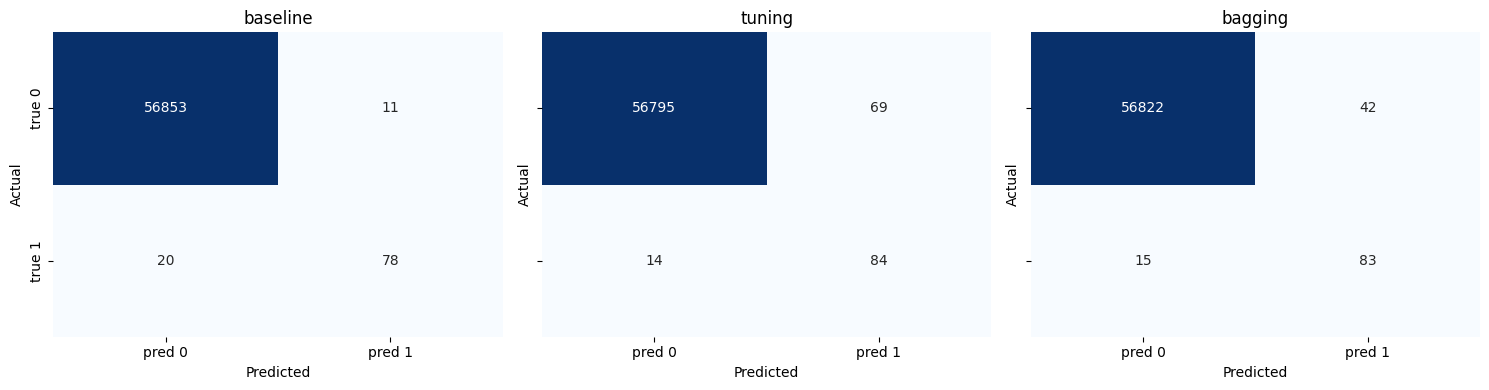

In [4]:
## Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, df) in zip(axes, preds.items()):

    # Calculate confusion-matrix counts with PySpark
    cm_row = df.agg(
        F.sum(
            F.when(
                (F.col("y_true") == 0) & (F.col("y_pred") == 0), 1
            ).otherwise(0)
        ).alias("TN"),

        F.sum(
            F.when(
                (F.col("y_true") == 0) & (F.col("y_pred") == 1), 1
            ).otherwise(0)
        ).alias("FP"),

        F.sum(
            F.when(
                (F.col("y_true") == 1) & (F.col("y_pred") == 0), 1
            ).otherwise(0)
        ).alias("FN"),

        F.sum(
            F.when(
                (F.col("y_true") == 1) & (F.col("y_pred") == 1), 1
            ).otherwise(0)
        ).alias("TP")
    ).collect()[0]

    # Build a 2x2 matrix from the Spark results
    cm = [
        [cm_row["TN"], cm_row["FP"]],
        [cm_row["FN"], cm_row["TP"]]
    ]

    # Plot with seaborn
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["pred 0", "pred 1"],
        yticklabels=["true 0", "true 1"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Metric Comparison Chart

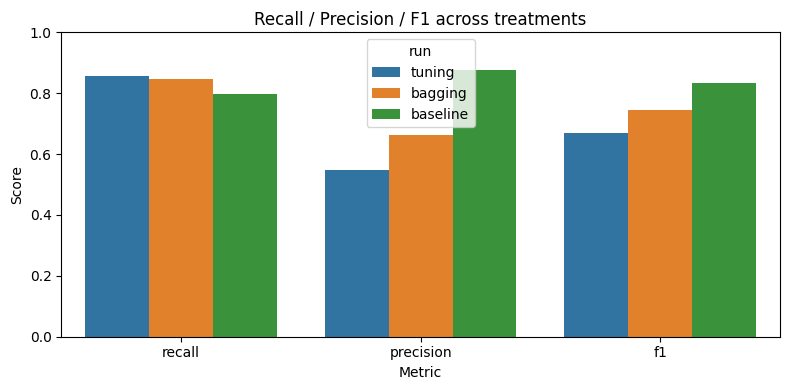

In [5]:
metric_order = ["recall", "precision", "f1"]
run_order = ["tuning", "bagging", "baseline"]

metrics_pd = metrics.toPandas()

plot_pd = metrics_pd.melt(
    id_vars="run",
    value_vars=["recall", "precision", "f1"],
    var_name="metric",
    value_name="score"
)

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=plot_pd,
    x="metric",
    y="score",
    hue="run",
    hue_order=run_order,
    order=metric_order,
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title("Recall / Precision / F1 across treatments")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

## Remarks

**Baseline:**

`XGBClassifier()` with no tuning catches *76 / 98* frauds (recall 0.7755) at 0.8539 precision. Even untuned, gradient boosting is a strong fraud baseline: tree splits are scale-invariant and the default `logloss` objective gradient-weights the rare positives, so XGB needs no explicit reweighting to be competitive.

**Tuning vs Baseline:**

`GridSearchCV` over `{n_estimators, max_depth, learning_rate, scale_pos_weight: [100]}` scored on recall lifts recall to *0.8571* (8 more frauds caught) but drops precision to *0.5600* and pushes false positives from 13 to *66*. This is the textbook recall–precision trade-off of class-weighted boosting: the moment you tell `GridSearchCV` to optimize recall on a 0.17%-positive problem, it picks the most aggressive `scale_pos_weight` it can.

**Bagging vs Baseline:**

Bagging 10 `GridSearchCV(XGB)` bags lands at recall *0.8367* and precision *0.8119*: it catches 6 more frauds than the baseline while only adding 6 false positives, holding precision essentially flat. This is the most balanced of the three. Bagging averages out the high-variance individual bags' tendency to overcommit on a single `scale_pos_weight` setting, so the ensemble decision boundary is steadier than any single tuned model's. The improvement over baseline is real but modest; on a test set with only 98 positives, differences of ±3 frauds are inside the noise of which specific transactions land in the test split.

**Overall:**

There is no single winner without an explicit cost model. If a missed fraud costs >> a manually-reviewed false positive, the *tuning* run is best despite its 0.27 precision. However, if review capacity is limited, *bagging* is the strongest balanced result, better recall than the baseline with comparable precision. The *baseline* remains a credible benchmark and the marginal value of expensive ensembling on this dataset is small if XGBoost is chosen model.